<a href="https://colab.research.google.com/github/katzemelli/thesis-edit-distance-nn/blob/main/notebooks/colab3_leaky_relu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab 3 — Leaky ReLU to fix gradient dead zones

In colab3_silu we found that swapping only the trainable layer activation to SiLU didn't help `DESIRE='01'`, the gradient for the weight that needs to reach 0 is still exactly zero, because the **frozen downstream ReLU layers** kill the gradient before it propagates back to the trainable weights, so we have the same issue as before with the normal ReLU function.

**Idea** Replace ReLU with Leaky ReLU (alpha=0.01) across **all** layers, including the frozen ones. The analytical weights still work correctly for positive inputs (Leaky ReLU = ReLU there), but now negative inputs pass a small gradient (0.01) instead of zero, hoping to avoid the vanishing gradient.

**Test plan:**
1. Train with `DESIRE='11'` — should still converge
2. Train with `DESIRE='01'` — the previously stuck case

In [6]:
import os

!git clone https://github.com/katzemelli/thesis-edit-distance-nn.git

os.chdir('/content/thesis-edit-distance-nn')

!ls sampledata/

fatal: destination path 'thesis-edit-distance-nn' already exists and is not an empty directory.
desired_length_2_levenshtein_2.csv  predtime_length_10_2_levenshtein.csv
desired_length_2_levenshtein_3.csv  predtime_length_5_4_levenshtein.csv
desired_length_2_levenshtein.csv    predtime_length_5_levenshtein.csv


In [7]:
!pip install tensorflow ml_dtypes --upgrade

In [8]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [9]:
import random
import time
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import statistics

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Input, add, Lambda, Reshape, concatenate, Flatten

LEAKY_ALPHA = 0.01  # negative slope — set to 0 to reproduce original ReLU behavior

def leaky_relu(x):
    return tf.nn.leaky_relu(x, alpha=LEAKY_ALPHA)

# Test params
test_input = tf.constant([-1.0, 0.0, 1.0])
print('leaky_relu([-1, 0, 1]) =', leaky_relu(test_input).numpy())

In [10]:
LEAKY_ALPHA = 0.01  # negative slope, set to 0 to reproduce original ReLU behavior

def leaky_relu(x):
    return tf.nn.leaky_relu(x, alpha=LEAKY_ALPHA)

# check
test_input = tf.constant([-1.0, 0.0, 1.0])
print('leaky_relu([-1, 0, 1]) =', leaky_relu(test_input).numpy())

leaky_relu([-1, 0, 1]) = [-0.01  0.    1.  ]


### Architecture — all ReLU replaced with Leaky ReLU

In [11]:
def transform_seqs_to_input(seqA, seqB):
    matching_pairs = []
    input_length_x = 0

    matching_pairs.append([int(seqA[0]), int(seqB[0])])
    if len(seqA) == 1 and len(seqB) == 1:
        return matching_pairs
    else:
        input_length_x = len(seqA)
        match_layers_i = (input_length_x * 2) - 1

    start_i = 1
    end_i = 2

    for l in range(match_layers_i):
        if l < input_length_x - 1:
            i, j = [*reversed(range(0, end_i))], [*range(0, end_i)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            end_i += 1
        else:
            i, j = [*reversed(range(start_i, input_length_x))], [*range(start_i, input_length_x)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            start_i += 1
            if start_i > len(seqB):
                break

    return matching_pairs


def transform_input_for_generate(input):
    x = []
    y = []
    for pair in input:
        x.append(pair[0])
        y.append(pair[1])
    return [x, y]

In [12]:
def matching_module():
    """Frozen module — now uses leaky_relu instead of relu."""
    epsilon = 1

    model = Sequential()
    model.add(Dense(units=2, activation=leaky_relu, use_bias=True, input_shape=(2,)))
    model.add(Dense(units=2, activation=leaky_relu, use_bias=True))
    model.add(Dense(units=1, activation=leaky_relu, use_bias=True))

    w1 = model.layers[0].get_weights()
    w1[0][0][0], w1[0][0][1] = 1.0, -1.0
    w1[0][1][0], w1[0][1][1] = -1.0, 1.0
    w1[1][0], w1[1][1] = 0, 0
    w2 = model.layers[1].get_weights()
    w2[0][0][0], w2[0][0][1] = 1.0, 1.0
    w2[0][1][0], w2[0][1][1] = 1.0, 1.0
    w2[1][0], w2[1][1] = epsilon, -1 * epsilon
    w3 = model.layers[2].get_weights()
    w3[0][0][0], w3[0][1][0] = (1.0/epsilon), -1.0 * (1.0/epsilon)
    w3[1][0] = -1

    model.layers[0].set_weights(w1)
    model.layers[1].set_weights(w2)
    model.layers[2].set_weights(w3)

    model.trainable = False
    return model


def min_module(i, j, k):
    """Frozen module — now uses leaky_relu instead of relu."""
    input = Input(shape=(2,))
    x = Dense(2, activation=leaky_relu, use_bias=True)(input)
    combined = concatenate([x, input])

    layer_name = 'result_pixel_' + str(i) + str(j) + '_' + str(k)
    z = Dense(1, activation=leaky_relu, use_bias=True, name=layer_name)(combined)
    model = Model(inputs=input, outputs=z)

    w1 = model.layers[1].get_weights()
    w1[0][0], w1[0][1] = [-1.0, 1.0], [1.0, -1.0]
    w2 = model.layers[3].get_weights()
    w2[0][0], w2[0][1], w2[0][2], w2[0][3] = -0.5, -0.5, 0.5, 0.5

    model.layers[1].set_weights(w1)
    model.layers[3].set_weights(w2)

    model.trainable = False
    return model


def minimum(i, j):
    """Frozen module — unchanged structure."""
    input = Input(shape=(3,))
    comp1_pair = Lambda(lambda x: x[:, :2], output_shape=(2,))(input)
    comp2_input = Lambda(lambda x: x[:, 2:], output_shape=(1,))(input)

    m = min_module(i, j, 1)(comp1_pair)
    comp2_pair = concatenate([comp2_input, m])
    output = min_module(i, j, 2)(comp2_pair)

    model = Model(inputs=input, outputs=output)
    model.trainable = False
    return model

In [13]:
def align_model_for_N(seq_length_x, seq_length_y, matching_pair_number):
    """Build the DP-mirroring NN. All activations use leaky_relu."""
    input = Input(shape=(2, matching_pair_number), name='input')

    y = Lambda(lambda t: t[:, 1, :], output_shape=(matching_pair_number,))(input)
    x = Lambda(lambda t: t[:, 0, :], output_shape=(matching_pair_number,))(input)

    out = {}
    start_i = 0
    step = 2
    for i in range(seq_length_y):
        a = start_i
        layername = 'for_gen_dense_' + str(i + 1)
        y_slice = Lambda(lambda t, a=a: t[:, a:a+1], output_shape=(1,))(y)
        z = Dense(1, activation=leaky_relu, name=layername, use_bias=False)(y_slice)
        out[layername] = z
        start_i += step
        step += 1

    pair_i = 1
    calc_layer = (seq_length_x * 2) - 1
    test_dict = {}

    # --- First pixel (1,1) ---
    y_dense_layer_name = 'for_gen_dense_1'
    densed_y = out[y_dense_layer_name]
    x_char = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(x)

    debug_name = 'matching_debug_1'
    pair_11 = concatenate([x_char, densed_y], name=debug_name)

    ext_gaps = Dense(2, activation=leaky_relu, name='first_calc_gap_layer')(pair_11)

    min1 = min_module(1, 1, 1)(ext_gaps)
    matching1 = matching_module()(pair_11)
    combined = concatenate([min1, matching1])
    z = min_module(1, 1, 2)(combined)
    result_pixel_11 = concatenate([ext_gaps, z], name='input_pixel_1_1')

    pair_i = 2

    if seq_length_x == 1 and seq_length_y == 1:
        output = z
        return Model(inputs=input, outputs=output)
    else:
        test_dict['input_pixel_1_1'] = result_pixel_11
        test_dict['result_pixel_1_1'] = z

        comp_i_val, comp_j_val = 1, 2
        start_sentinel, end_sentinel = 1, 2
        unbalance_flag = True

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_length_x - 1:
                comp_i_val, comp_j_val = start_sentinel, end_sentinel
                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_i = comp_i_val
                        y_dense_layer_name = 'for_gen_dense_' + str(y_i)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)

                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        if comp_i_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        elif comp_j_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        else:
                            previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                            previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                            previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                            before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation=leaky_relu, name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                if end_sentinel + 1 <= seq_length_x:
                    end_sentinel += 1

            else:
                start_sentinel += 1
                comp_i_val, comp_j_val = start_sentinel, end_sentinel

                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_dense_layer_name = 'for_gen_dense_' + str(comp_i_val)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)
                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                        previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                        previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                        before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation=leaky_relu, name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                    if start_sentinel == end_sentinel:
                        return Model(inputs=input, outputs=result_pixel)

In [14]:
def set_weight_for_debug(model, seq_len_x, seq_len_y, matching_pair):
    print('setting weights ...')

    for i in range(seq_len_y):
        lname = 'for_gen_dense_' + str(i+1)
        weights = model.get_layer(lname).get_weights()
        weights[0][0][0] = random.uniform(0, 1)
        model.get_layer(lname).set_weights(weights)

    w = model.get_layer('first_calc_gap_layer').get_weights()
    w[0][0][0], w[0][0][1] = 0, 0
    w[0][1][0], w[0][1][1] = 0, 0
    w[1][0], w[1][1] = 2, 2
    model.get_layer('first_calc_gap_layer').set_weights(w)
    model.get_layer('first_calc_gap_layer').trainable = False

    if seq_len_x > 1:
        calc_layer = (seq_len_x * 2) - 1
        comp_i, comp_j = 1, 2
        start_sentinel, end_sentinel = 1, 2

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_len_x - 1:
                comp_i, comp_j = start_sentinel, end_sentinel
                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        if comp_i == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        elif comp_j == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        else:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, 0

                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)
                if end_sentinel + 1 <= seq_len_x:
                    end_sentinel += 1
            else:
                start_sentinel = start_sentinel + 1
                comp_i, comp_j = start_sentinel, end_sentinel

                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                        w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                        w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                        w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                        w[1][0], w[1][1], w[1][2] = 1, 1, 0
                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)


def froozen_align_model(model):
    print('frozen parameters in network for alignment ...')
    for layer in model.layers:
        if 'for_gen_dense' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

In [15]:
def plot_progress_weights(progress_weights, epoch, desire, title=''):
    x = [*range(epoch+1)]

    color_cycle = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    markers = ['o', 's', '^', 'v', '*']
    plt.figure(figsize=(18, 10), dpi=100)

    y_s = np.array(progress_weights).T
    w_i = 0
    for y in y_s:
        m = markers[w_i % len(markers)]
        plt.plot(x, y, marker=m, label='weight' + str(w_i+1), color=color_cycle[w_i])
        plt.hlines(desire[w_i], 0, epoch, color=color_cycle[w_i], linestyles='dotted')
        w_i += 1

    plt.xlabel('epochs')
    plt.ylabel('weight')
    plt.ylim(-0.5, 1.5)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=10)
    plt.show()

In [16]:
def training(desire_str, filename, epochs=20, seed=None):
    """Run training and return results dict for comparison."""
    if seed is not None:
        random.seed(seed)

    DESIRE = desire_str
    LEN = len(DESIRE)

    lines = []
    with open(filename, 'r') as f:
        for line in f:
            line.rstrip('\n')
            lines.append(line)

    confirm_l = lines[0]
    sp = confirm_l.split(',')
    x, y = sp[0], sp[1]
    pairs = transform_seqs_to_input(x, y)
    SEQ_LEN_X = len(x)
    SEQ_LEN_Y = len(y)
    PAIRS_LEN = len(pairs)

    model = align_model_for_N(SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    set_weight_for_debug(model, SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    froozen_align_model(model)

    init_trained_weights = []
    for layer in model.layers:
        if 'for_gen_dense' in layer.name:
            weight = layer.get_weights()
            init_trained_weights.append(float(weight[0][0]))
    init_trained_weights.reverse()

    progress_weights = []
    progress_weight = []
    for i in range(LEN):
        lname = 'for_gen_dense_' + str(i+1)
        weights = model.get_layer(lname).get_weights()
        progress_weight.append(weights[0][0][0])
    progress_weights.append(progress_weight)

    optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
    loss_fn = tf.keras.losses.MeanSquaredError()

    losses = []
    for epoch in range(epochs):
        print(f'Epoch {epoch}')

        loss = tf.Variable(0.0, name='loss')
        with tf.GradientTape() as tape:
            for line in lines:
                sp = line.split(',')
                x, y, true_score = sp[0], sp[1], int(sp[2])
                input = transform_seqs_to_input(x, y)
                input = transform_input_for_generate(input)
                input = tf.constant([input])
                logit = model(input, training=True)
                loss = loss + loss_fn(true_score, logit)
            batch_loss = loss / len(lines)
            print(batch_loss)
            grads = tape.gradient(batch_loss, model.trainable_weights)
            optimizer.apply_gradients(zip(grads, model.trainable_weights))

        losses.append(float(batch_loss))

        progress_weight = []
        for i in range(LEN):
            lname = 'for_gen_dense_' + str(i+1)
            weights = model.get_layer(lname).get_weights()
            progress_weight.append(weights[0][0][0])
        progress_weights.append(progress_weight)

    raw_trained_weights = []
    for layer in model.layers:
        if 'for_gen_dense' in layer.name:
            weight = layer.get_weights()
            raw_trained_weights.append(float(weight[0][0]))
    raw_trained_weights.reverse()

    print('init weights:', init_trained_weights)
    print('raw trained weights:', raw_trained_weights)

    d = [int(i) for i in DESIRE]
    title = f'DESIRE={DESIRE} | Leaky ReLU (alpha={LEAKY_ALPHA})'
    plot_progress_weights(progress_weights, epochs, d, title=title)

    return {
        'desire': DESIRE,
        'activation': f'leaky_relu(alpha={LEAKY_ALPHA})',
        'init_weights': init_trained_weights,
        'final_weights': raw_trained_weights,
        'losses': losses,
        'progress_weights': progress_weights
    }

### Experiment 1: DESIRE='11' (should still converge)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


setting weights ...
frozen parameters in network for alignment ...
Epoch 0


/tmp/ipykernel_8162/634333588.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  init_trained_weights.append(float(weight[0][0]))


tf.Tensor(0.2096817, shape=(), dtype=float32)
Epoch 1
tf.Tensor(0.13783738, shape=(), dtype=float32)
Epoch 2
tf.Tensor(0.090633005, shape=(), dtype=float32)
Epoch 3
tf.Tensor(0.059617694, shape=(), dtype=float32)
Epoch 4
tf.Tensor(0.039239146, shape=(), dtype=float32)
Epoch 5
tf.Tensor(0.025849223, shape=(), dtype=float32)
Epoch 6
tf.Tensor(0.017051179, shape=(), dtype=float32)
Epoch 7
tf.Tensor(0.0112702325, shape=(), dtype=float32)
Epoch 8
tf.Tensor(0.007471719, shape=(), dtype=float32)
Epoch 9
tf.Tensor(0.0049757445, shape=(), dtype=float32)
Epoch 10
tf.Tensor(0.0033356657, shape=(), dtype=float32)
Epoch 11
tf.Tensor(0.0022579692, shape=(), dtype=float32)
Epoch 12
tf.Tensor(0.001549811, shape=(), dtype=float32)
Epoch 13
tf.Tensor(0.0010844774, shape=(), dtype=float32)
Epoch 14
tf.Tensor(0.0008427499, shape=(), dtype=float32)
Epoch 15
tf.Tensor(0.0006785194, shape=(), dtype=float32)
Epoch 16
tf.Tensor(0.0005532862, shape=(), dtype=float32)
Epoch 17
tf.Tensor(0.0006055298, shape=(), d

/tmp/ipykernel_8162/634333588.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  raw_trained_weights.append(float(weight[0][0]))


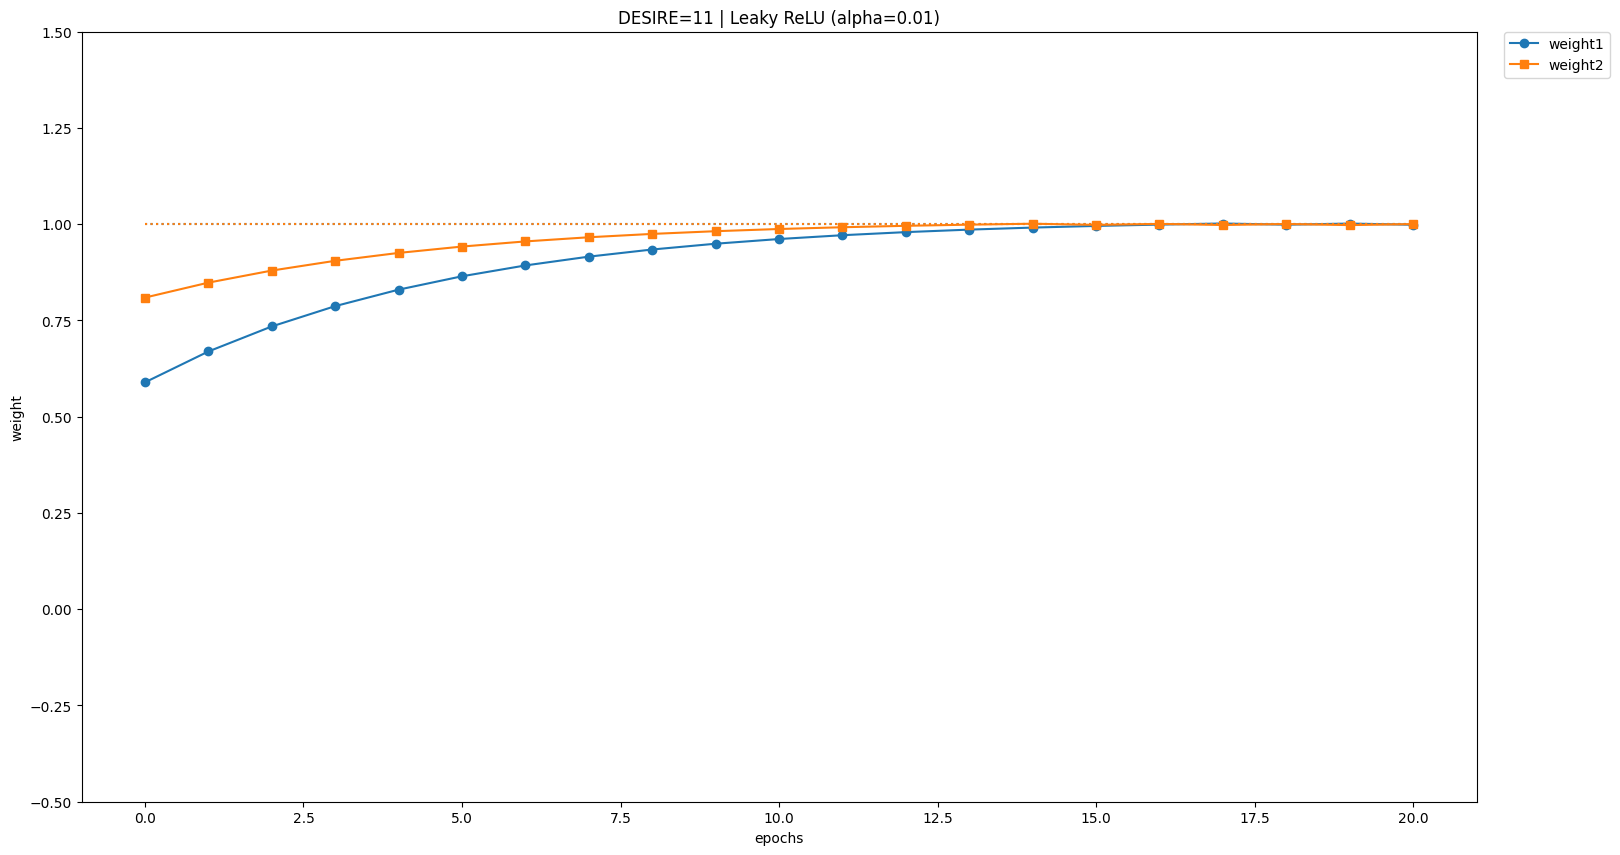

In [17]:
result_11 = training(
    desire_str='11',
    filename='/content/thesis-edit-distance-nn/sampledata/desired_length_2_levenshtein_2.csv',
    epochs=20,
    seed=42
)

### Experiment 2: DESIRE='01' (previously stuck with ReLU)

setting weights ...
frozen parameters in network for alignment ...
Epoch 0


/tmp/ipykernel_8162/634333588.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  init_trained_weights.append(float(weight[0][0]))


tf.Tensor(0.039785754, shape=(), dtype=float32)
Epoch 1
tf.Tensor(0.026191533, shape=(), dtype=float32)
Epoch 2
tf.Tensor(0.01728719, shape=(), dtype=float32)
Epoch 3
tf.Tensor(0.0114547, shape=(), dtype=float32)
Epoch 4
tf.Tensor(0.0076343836, shape=(), dtype=float32)
Epoch 5
tf.Tensor(0.005132014, shape=(), dtype=float32)
Epoch 6
tf.Tensor(0.0034929425, shape=(), dtype=float32)
Epoch 7
tf.Tensor(0.0024193367, shape=(), dtype=float32)
Epoch 8
tf.Tensor(0.0017161049, shape=(), dtype=float32)
Epoch 9
tf.Tensor(0.001255482, shape=(), dtype=float32)
Epoch 10
tf.Tensor(0.0009537737, shape=(), dtype=float32)
Epoch 11
tf.Tensor(0.00075614796, shape=(), dtype=float32)
Epoch 12
tf.Tensor(0.000626703, shape=(), dtype=float32)
Epoch 13
tf.Tensor(0.000541915, shape=(), dtype=float32)
Epoch 14
tf.Tensor(0.00059503724, shape=(), dtype=float32)
Epoch 15
tf.Tensor(0.0005524151, shape=(), dtype=float32)
Epoch 16
tf.Tensor(0.0005853756, shape=(), dtype=float32)
Epoch 17
tf.Tensor(0.00055946724, shape=(

/tmp/ipykernel_8162/634333588.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  raw_trained_weights.append(float(weight[0][0]))


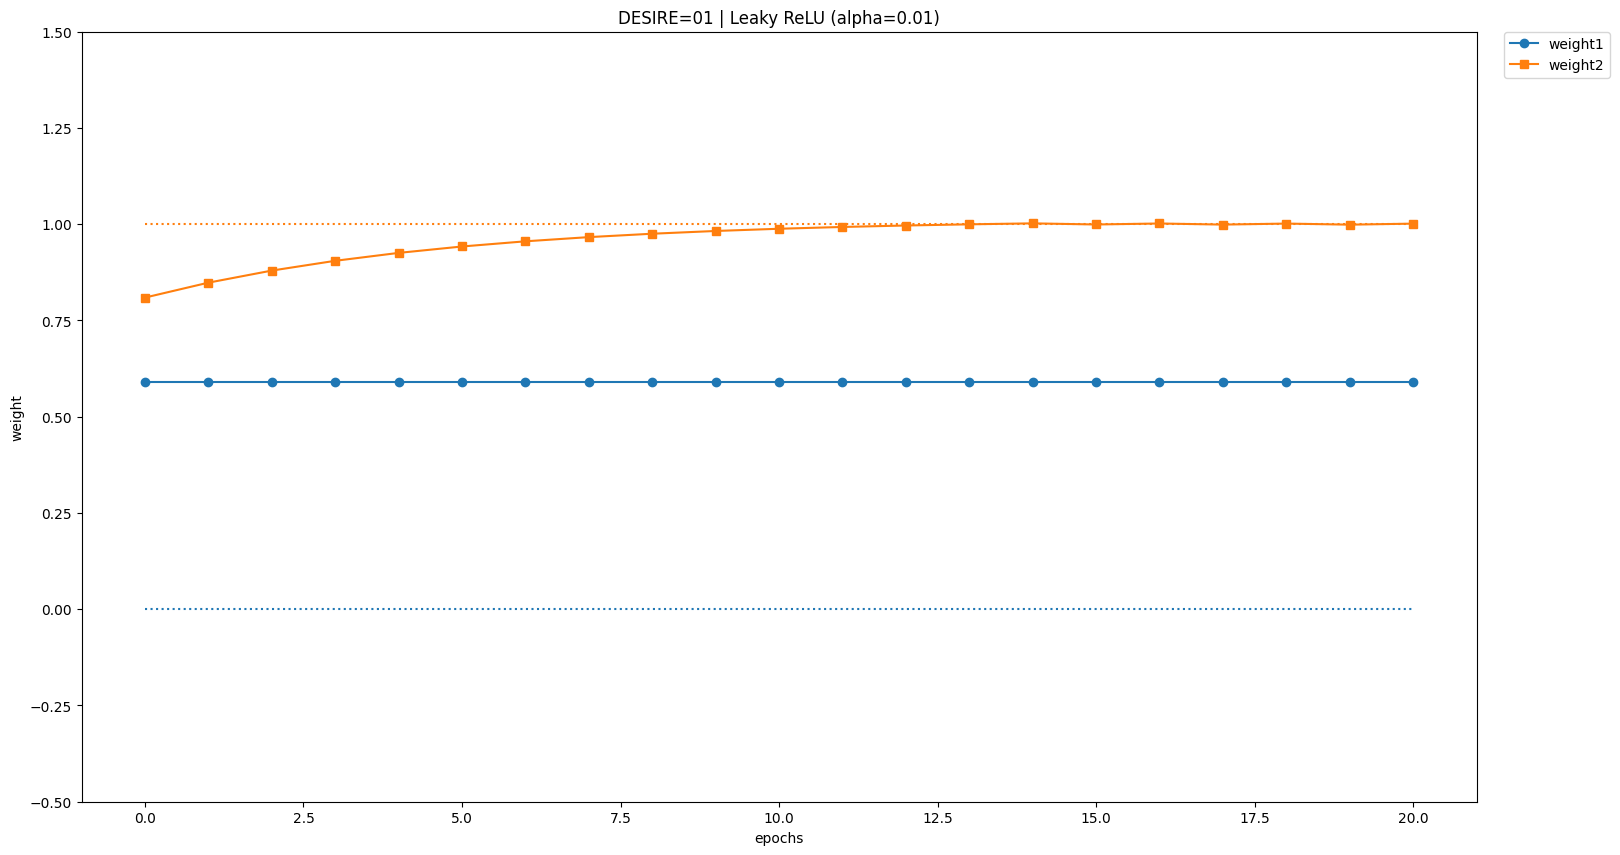

In [18]:
result_01 = training(
    desire_str='01',
    filename='/content/thesis-edit-distance-nn/sampledata/desired_length_2_levenshtein_3.csv',
    epochs=20,
    seed=42
)

### Loss comparison

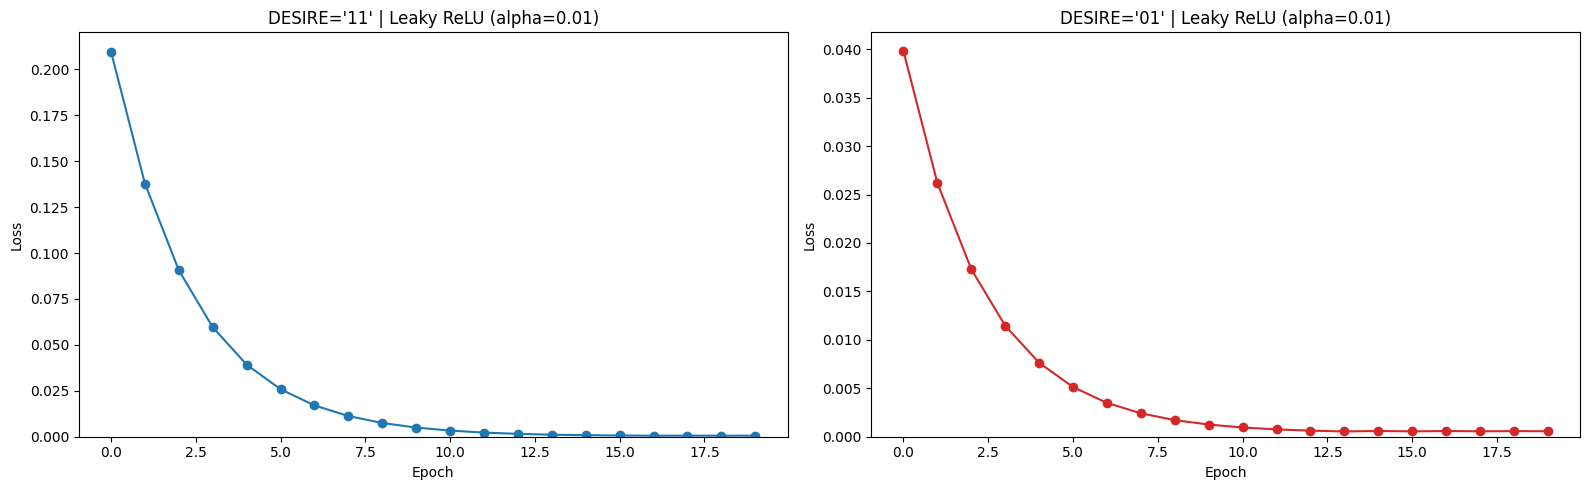

DESIRE='11' final loss: 0.000606
DESIRE='11' final weights: [1.0003485679626465, 0.9986639022827148]

DESIRE='01' final loss: 0.000564
DESIRE='01' final weights: [1.0015140771865845, 0.5892657041549683]


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(result_11['losses'], marker='o')
ax1.set_title(f"DESIRE='11' | Leaky ReLU (alpha={LEAKY_ALPHA})")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_ylim(bottom=0)

ax2.plot(result_01['losses'], marker='o', color='#d62728')
ax2.set_title(f"DESIRE='01' | Leaky ReLU (alpha={LEAKY_ALPHA})")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f"DESIRE='11' final loss: {result_11['losses'][-1]:.6f}")
print(f"DESIRE='11' final weights: {result_11['final_weights']}")
print()
print(f"DESIRE='01' final loss: {result_01['losses'][-1]:.6f}")
print(f"DESIRE='01' final weights: {result_01['final_weights']}")